# 08. Neuronale Netze

---

> **Neuronales Netz**: Ein aus vielen einfachen Recheneinheiten ("Neuronen") aufgebautes Modell, das durch das Hintereinanderschalten linearer Transformationen und nichtlinearer Aktivierungsfunktionen beliebig komplexe, nichtlineare Zusammenhänge approximieren kann.

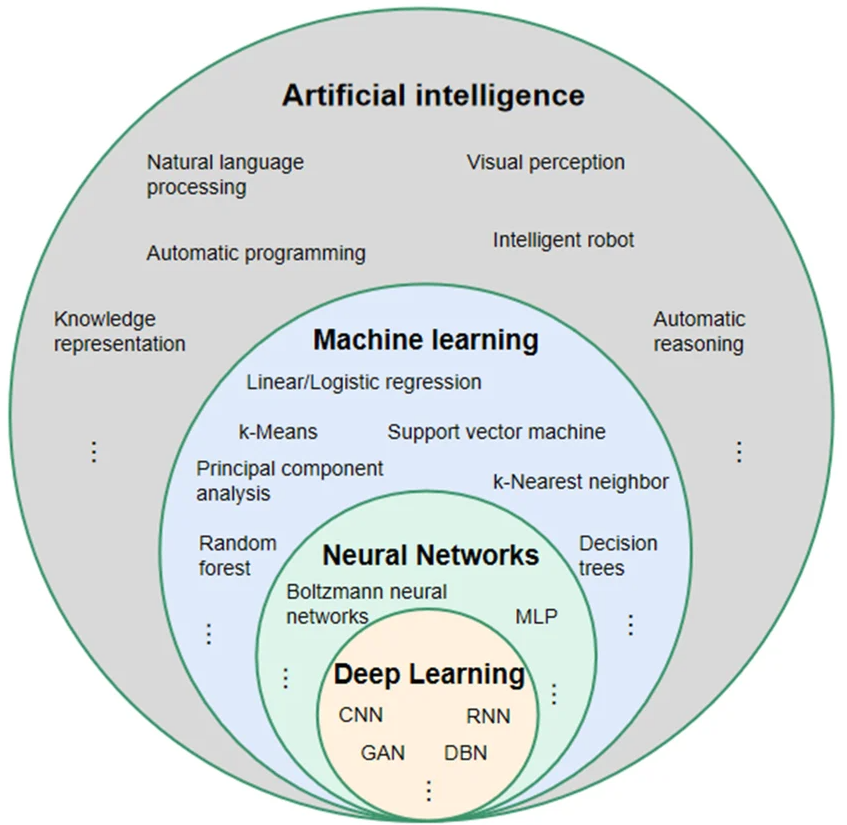

Bild-Quelle: Li, Song & Deng, Yu-Qin & Zhu, Zhi-Ling & Hua, Hong-Li & Tao, Ze-Zhang. (2021). A Comprehensive Review on Radiomics and Deep Learning for Nasopharyngeal Carcinoma Imaging. Diagnostics. 

## 8.1 Motivation

Bisher haben wir folgende Modellfamilien kennengelernt:

* **Logistische Regression** – ein rein *lineares* Modell
* **Entscheidungsbäume** – erzeugen *stückweise-konstante* Entscheidungsflächen
* **Random Forests / Boosting (AdaBoost, Gradient Boosting, XGBoost)** – Ensembles aus vielen Bäumen

Diese Modelle sind sehr leistungsfähig für tabellarische Daten – stoßen aber an Grenzen:

* Logistische Regression kann nur **lineare** Entscheidungsgrenzen lernen.
* Entscheidungsbäume approximieren Funktionen **stückweise** und extrapolieren schlecht.
* Viele reale Probleme (Bilder, Sprache, Sensorik, komplexe Interaktionen) sind **hochgradig nichtlinear**.

**Zentrale Frage:** Wie modellieren wir komplexe, nichtlineare Zusammenhänge, ohne zuvor Features von Hand zu konstruieren?

**Antwort:** Neuronale Netze – sie lernen automatisch nützliche, nichtlineare Repräsentationen der Daten.

In diesem Notebook verschaffen wir uns einen **fundierten Überblick** über neuronale Netze:
Aufbau, Forward Pass, Loss, Backpropagation, Training und Regularisierung. Weiterführende Deep-Learning-Architekturen umfassen beispielsweise Convolutional Neural Networks (CNNs), Recurrent Neural Networks (RNNs), Transformer, ...


## 8.2 Beispiel Titanic: Vom linearen Modell zum neuronalen Netz

Wie in den vorherigen Notebooks arbeiten wir durchgehend am **Titanic-Datensatz**, damit wir neuronale Netze direkt mit den bereits bekannten Modellen vergleichen können.

Ablauf dieses Notebooks:

1. Daten laden & Preprocessing-Pipeline (Wiederholung)
2. Baseline-Modelle (LogReg, Decision Tree, Random Forest) als Vergleichsmaßstab
3. Warum reichen klassische Modelle nicht immer aus? (Motivation anhand eines synthetischen Beispiels)
4. Bausteine eines neuronalen Netzes: Neuron, Layer, Aktivierungsfunktionen
5. Forward Pass & Loss – Schritt für Schritt von Hand nachgerechnet
6. Training: Backpropagation & Gradientenabstieg
7. Hyperparameter des Trainings (Lernrate, Batch Size, Optimizer)
8. Regularisierung & Stabilität (Weight Decay, Dropout, Vanishing Gradients)
9. Ein neuronales Netz auf dem Titanic-Datensatz
10. Hyperparameter-Tuning & Overfitting in der Praxis
11. Gesamtvergleich aller Modelle
12. Fazit & Ausblick


## Kapitel 1: Daten laden und Preprocessing-Pipeline (Wiederholung)

Wir verwenden erneut den **Titanic-Datensatz** aus `seaborn`, mit derselben Feature-Auswahl und demselben Train/Test-Split wie in den vorherigen Notebooks. So bleiben alle Modelle direkt vergleichbar.

Zielvariable: `survived`


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Titanic-Datensatz aus seaborn laden
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Zielvariable definieren
target_col = "survived"

# Feature-Auswahl (identisch zu den vorherigen Notebooks)
drop_cols = [
    target_col,
    "alive",    # textuelle Version der Zielvariable -> Datenleckage
    "class"     # textuelle Version von pclass
]

feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df[target_col].copy()

# Numerische und kategoriale Features bestimmen
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "bool", "category"]).columns.tolist()

print("Numerische Features:", numeric_features)
print("Kategoriale Features:", categorical_features)

# Train/Test-Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train.shape, X_test.shape

Numerische Features: ['pclass', 'age', 'sibsp', 'parch', 'fare']
Kategoriale Features: ['sex', 'embarked', 'who', 'adult_male', 'deck', 'embark_town', 'alone']


c:\temp\ipykernel_22704\3548551245.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "bool", "category"]).columns.tolist()


((712, 12), (179, 12))

### Preprocessing-Pipeline

Neuronale Netze reagieren – anders als Entscheidungsbäume – **sehr empfindlich auf die Skala der Eingabedaten**: Gradientenabstieg funktioniert nur gut, wenn alle Features eine vergleichbare Größenordnung haben. Standardisierung ist bei neuronalen Netzen daher nicht optional, sondern Pflicht.

Wir verwenden dieselbe Pipeline wie zuvor:

1. Imputation fehlender Werte (Median bzw. häufigste Kategorie)
2. Standardisierung numerischer Variablen: $z = \dfrac{x - \mu}{\sigma}$
3. One-Hot-Encoding kategorialer Variablen
4. Zusammenführung über einen `ColumnTransformer`


In [4]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Pipeline für numerische Spalten
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Pipeline für kategoriale Spalten
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Gemeinsamer ColumnTransformer
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

X_train_trans = preprocess.fit_transform(X_train)
feature_names_all = preprocess.get_feature_names_out()

X_train_trans.shape, len(feature_names_all)

((712, 27), 27)

### Fazit Kapitel 1

* Der Titanic-Datensatz ist geladen, Features und Zielvariable sind definiert.
* Die Preprocessing-Pipeline (Imputation, Standardisierung, One-Hot-Encoding) ist identisch zu den vorherigen Notebooks – dadurch bleiben alle Modelle fair vergleichbar.
* Insbesondere die **Standardisierung** ist für das kommende neuronale Netz entscheidend.

Im nächsten Kapitel trainieren wir zunächst die bekannten Baseline-Modelle, bevor wir uns dem neuronalen Netz zuwenden.


## Kapitel 2: Baseline-Modelle im Überblick (Recap)

Bevor wir neuronale Netze einführen, wiederholen wir kurz die bereits bekannten Modelle und erzeugen damit einen **Vergleichsmaßstab (Baseline)**. Wir verwenden wieder eine einheitliche Evaluationsfunktion und speichern alle Ergebnisse zentral im Dictionary `model_results`, das wir am Ende des Notebooks um das neuronale Netz erweitern.


In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

model_results = {}  # zentrales Dict für alle Modelle dieses Notebooks

def evaluate_model(name, model, X_train, y_train, X_test, y_test, plot_cm=True):
    '''Trainiert das Modell, berechnet Metriken und speichert alles in model_results[name].'''
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        roc_auc = float("nan")

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    train_acc = accuracy_score(y_train, model.predict(X_train))

    metrics = {
        "Train-Accuracy": train_acc,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": roc_auc,
    }

    print(f"=== {name} ===")
    for k, v in metrics.items():
        print(f"{k:>15}: {v:.3f}")
    print()

    if plot_cm:
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["nicht überlebt (0)", "überlebt (1)"],
        )
        disp.plot(values_format="d")
        plt.title(f"Confusion Matrix – {name}")
        plt.tight_layout()
        plt.show()

    model_results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "metrics": metrics,
    }

    return metrics

In [6]:
from sklearn.linear_model import LogisticRegression

logreg_clf = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logreg_metrics = evaluate_model(
    name="Logistische Regression",
    model=logreg_clf,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    plot_cm=False
)

=== Logistische Regression ===
 Train-Accuracy: 0.829
       Accuracy: 0.827
      Precision: 0.788
         Recall: 0.754
             F1: 0.770
        ROC-AUC: 0.863



In [7]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(max_depth=4, random_state=42))
    ]
)

dt_metrics = evaluate_model(
    name="Entscheidungsbaum",
    model=dt_clf,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    plot_cm=False
)

=== Entscheidungsbaum ===
 Train-Accuracy: 0.855
       Accuracy: 0.810
      Precision: 0.778
         Recall: 0.710
             F1: 0.742
        ROC-AUC: 0.852



In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42))
    ]
)

rf_metrics = evaluate_model(
    name="Random Forest",
    model=rf_clf,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    plot_cm=False
)

=== Random Forest ===
 Train-Accuracy: 0.985
       Accuracy: 0.816
      Precision: 0.810
         Recall: 0.681
             F1: 0.740
        ROC-AUC: 0.836



In [9]:
baseline_df = pd.DataFrame({
    name: res["metrics"] for name, res in model_results.items()
}).T

baseline_df

,Train-Accuracy,Accuracy,Precision,Recall,F1,ROC-AUC
Logistische Regression,0.828652,0.826816,0.787879,0.753623,0.770370,0.863373
Entscheidungsbaum,0.855337,0.810056,0.777778,0.710145,0.742424,0.852437
Random Forest,0.984551,0.815642,0.810345,0.681159,0.740157,0.835639


### Fazit Kapitel 2

Wir haben drei bekannte Modelle als Baseline trainiert. Alle liegen bei einer Accuracy von grob 78–83 % – ein solider, aber nicht perfekter Wert. Die spannende Frage lautet nun:

**Kann ein neuronales Netz auf diesen (eher kleinen, tabellarischen) Daten etwas dazugewinnen – und wann lohnt sich der Einsatz überhaupt?**

Bevor wir das am Titanic-Datensatz testen, schauen wir uns an einem einfachen, synthetischen Beispiel an, *warum* neuronale Netze grundsätzlich mehr können als lineare Modelle und einzelne Bäume.


## Kapitel 3: Warum reichen klassische Modelle nicht immer aus?

Klassische ML-Modelle stoßen bei bestimmten Datenstrukturen an ihre Grenzen:

* Logistische Regression lernt nur **lineare** Entscheidungsgrenzen.
* Entscheidungsbäume erzeugen **stückweise-konstante** Funktionen.
* Feature Engineering (manuelle Konstruktion nichtlinearer Features) ist oft mühsam oder unzureichend.
* Viele reale Probleme sind **hochgradig nichtlinear** (Bilder, Sprache, Sensorik).

Wir demonstrieren das an einem klassischen Beispiel: einem **Ring-Datensatz**, bei dem eine Klasse einen inneren Kreis bildet und die andere Klasse einen äußeren Ring darum.


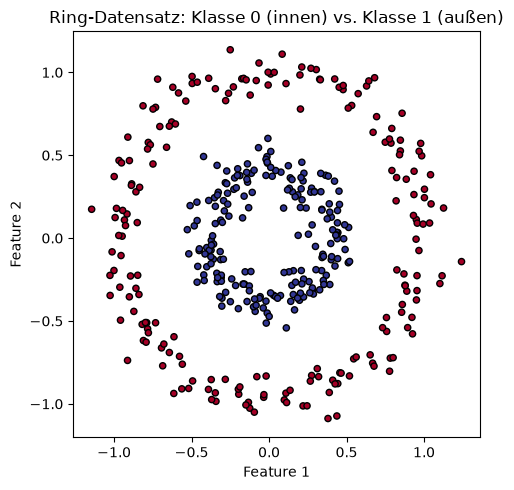

In [10]:
from sklearn.datasets import make_circles

X_ring, y_ring = make_circles(n_samples=400, noise=0.08, factor=0.4, random_state=42)

plt.figure(figsize=(5, 5))
plt.scatter(X_ring[:, 0], X_ring[:, 1], c=y_ring, cmap="RdYlBu", edgecolor="k", s=20)
plt.title("Ring-Datensatz: Klasse 0 (innen) vs. Klasse 1 (außen)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

Eine lineare Entscheidungsgrenze kann Kreis und Ring grundsätzlich nicht trennen – egal wie die Gerade gelegt wird, liegen immer Punkte beider Klassen auf derselben Seite. Ein Entscheidungsbaum kann sich der runden Form nur **stückweise, treppenförmig** annähern. Wir vergleichen daher drei Modelle auf denselben Daten:

* Logistische Regression
* Entscheidungsbaum (`max_depth=4`)
* Ein kleines **neuronales Netz** (`MLPClassifier`, zwei Hidden-Layer)


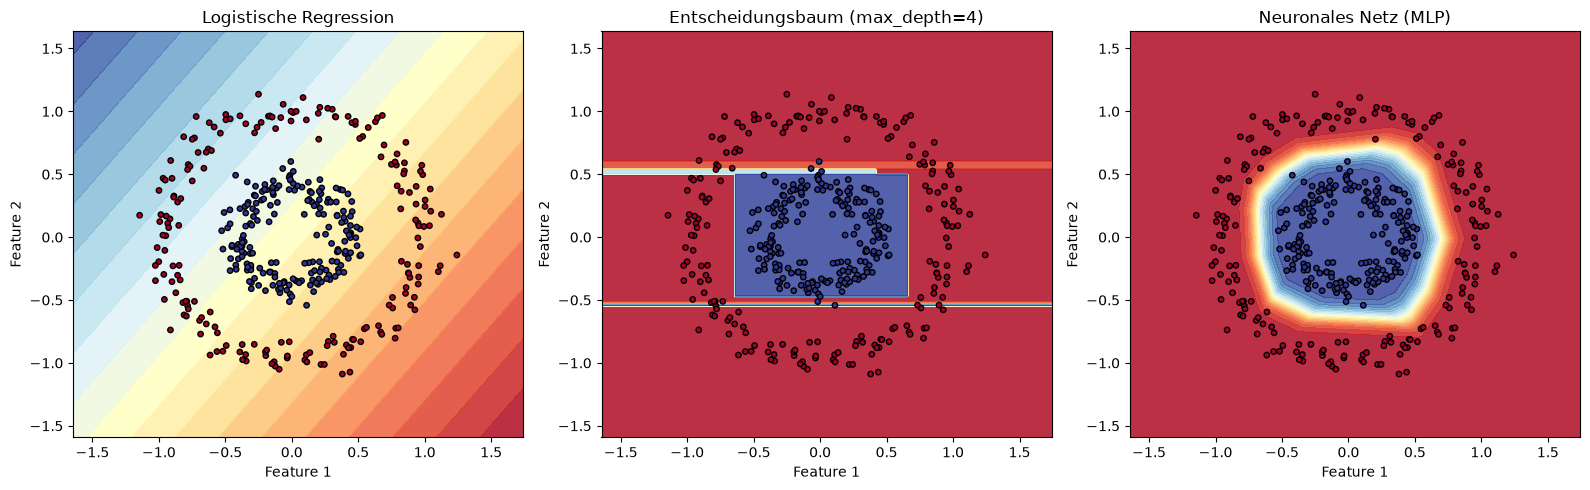

In [11]:
from sklearn.linear_model import LogisticRegression as LR_demo
from sklearn.tree import DecisionTreeClassifier as DT_demo
from sklearn.neural_network import MLPClassifier

demo_models = {
    "Logistische Regression": LR_demo(),
    "Entscheidungsbaum (max_depth=4)": DT_demo(max_depth=4, random_state=42),
    "Neuronales Netz (MLP)": MLPClassifier(
        hidden_layer_sizes=(16, 16),
        activation="relu",
        max_iter=2000,
        random_state=42
    ),
}

xx, yy = np.meshgrid(
    np.linspace(X_ring[:, 0].min() - 0.5, X_ring[:, 0].max() + 0.5, 300),
    np.linspace(X_ring[:, 1].min() - 0.5, X_ring[:, 1].max() + 0.5, 300),
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, model) in zip(axes, demo_models.items()):
    model.fit(X_ring, y_ring)
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=20, cmap="RdYlBu", alpha=0.85)
    ax.scatter(X_ring[:, 0], X_ring[:, 1], c=y_ring, cmap="RdYlBu", edgecolor="k", s=15)
    ax.set_title(name)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

**Beobachtung:**

* Die **logistische Regression** legt eine gerade Trennlinie – sie kann den Ring nicht sinnvoll abbilden.
* Der **Entscheidungsbaum** nähert die runde Grenze durch rechteckige Stufen an – besser, aber immer noch kantig und stark von `max_depth` abhängig.
* Das **neuronale Netz** lernt eine glatte, runde Entscheidungsgrenze, die dem wahren Muster sehr nahekommt.

### Kernidee neuronaler Netze

Was macht neuronale Netze besonders?

* Sie lernen **automatisch** nützliche, nichtlineare Repräsentationen aus den Daten – ohne dass wir manuell Features wie $x_1^2 + x_2^2$ konstruieren müssen.
* Jede Schicht ("Layer") **verbiegt** den Feature-Raum ein Stück.
* Viele Schichten hintereinander erlauben **hochgradig nichtlineare** Abbildungen.

> *„Ein neuronales Netz ist ein großer geometrischer Verbieger des Feature-Raums."*

Intuitiv gilt: Viele lineare Transformationen kombiniert mit Nichtlinearitäten ergeben einen **universellen Funktionsapproximator** – ein neuronales Netz kann (bei ausreichender Größe) praktisch jede stetige Funktion beliebig genau annähern. Zudem skalieren neuronale Netze sehr gut mit großen Datenmengen und hoher Dimensionalität, und sie lernen Hierarchien: einfache Muster in frühen Schichten, komplexere Kombinationen in späteren Schichten.


### Fazit Kapitel 3

* Lineare Modelle und einzelne Bäume haben strukturelle Grenzen bei nichtlinearen Mustern.
* Neuronale Netze lernen glatte, flexible Entscheidungsgrenzen, indem sie viele einfache Bausteine (Neuronen) kombinieren.
* Diese Flexibilität hat aber auch einen Preis: mehr Parameter, schwierigere Optimierung, höheres Overfitting-Risiko, geringere Interpretierbarkeit – Themen, denen wir uns in den folgenden Kapiteln widmen.

Als Nächstes schauen wir uns an, **woraus** ein neuronales Netz eigentlich besteht.


## Kapitel 4: Bausteine eines neuronalen Netzes

### Was ist ein Neuron?

Ein einzelnes Neuron berechnet zunächst eine **lineare Kombination** seiner Eingaben und wendet anschließend eine **Aktivierungsfunktion** an:

$$
z = w^\top x + b, \qquad a = \varphi(z)
$$

wobei

* $x$: Eingabevektor (Features)
* $w$: Gewichte, $b$: Bias
* $\varphi$: Aktivierungsfunktion (Nichtlinearität)

Das ist strukturell identisch zur logistischen Regression! Tatsächlich ist ein einzelnes Neuron mit Sigmoid-Aktivierung nichts anderes als eine logistische Regression:

$$
\hat y = \sigma(z) = \sigma(w^\top x + b)
$$

Ein einzelnes Neuron beschreibt daher – genau wie die logistische Regression – nur eine **Hyper-Ebene** $w^\top x + b = 0$ im Feature-Raum und kann somit nur linear trennbare Strukturen abbilden. Die eigentliche Stärke neuronaler Netze entsteht erst durch das **Kombinieren vieler Neuronen in Schichten**.


### Von einem Neuron zu einer Schicht (Layer)

Ein **Hidden-Layer** besteht aus mehreren Neuronen, die parallel auf denselben Input angewendet werden:

$$
z_j^{(1)} = (w_j^{(1)})^\top x + b_j^{(1)}, \qquad h_j^{(1)} = \varphi\!\left(z_j^{(1)}\right), \qquad j = 1, \dots, m
$$

Kompakt in Matrixschreibweise für eine ganze Schicht $l$:

$$
h^{(l)} = \varphi\!\left(W^{(l)} h^{(l-1)} + b^{(l)}\right)
$$

Ein vollständiges Feedforward-Netz besteht aus:

* **Input-Layer**: die rohen Features
* **Hidden-Layer(s)**: lernen Zwischenrepräsentationen
* **Output-Layer**: liefert die finale Vorhersage (z. B. Logit bzw. Wahrscheinlichkeit)

**Intuition:** Jedes Neuron einer Schicht definiert seine eigene Hyper-Ebene und teilt den Raum in Regionen ein. Das Ergebnis ist zunächst eine **stückweise lineare Approximation**. Die nächste Schicht kombiniert diese Regionen erneut linear – dadurch entstehen zunehmend komplexe, gekrümmte Entscheidungsgrenzen. Man kann sich einen Hidden-Layer als einen Satz von "Basis-Schnitten" vorstellen, aus denen spätere Schichten eine komplizierte Oberfläche zusammensetzen.

### Mehrere Layer = gestufte Repräsentationen

Werden mehrere Schichten hintereinandergeschaltet,

$$
h^{(1)} = \varphi\!\left(W^{(1)} x + b^{(1)}\right), \qquad
h^{(2)} = \varphi\!\left(W^{(2)} h^{(1)} + b^{(2)}\right), \qquad \dots
$$

entstehen zunehmend abstrakte Repräsentationen: frühe Schichten lernen einfache Muster (Kombinationen einzelner Features), spätere Schichten kombinieren diese zu komplexeren Strukturen. Bei Bilddaten wird dieses Prinzip besonders anschaulich: Rohdaten (Pixel) → Kanten → Formen → Objekte.


### Aktivierungsfunktionen

Ohne Aktivierungsfunktion wäre jede Schicht rein linear:

$$
h^{(l)} = W^{(l)} h^{(l-1)} + b^{(l)}
$$

Eine Verkettung linearer Abbildungen ist wieder nur linear – ein "tiefes" Netz ohne Aktivierungen wäre also **genauso ausdrucksstark wie eine lineare Regression**! Erst die Aktivierungsfunktion $\varphi$ fügt eine **Nichtlinearität** hinzu und erlaubt es dem Netz, beliebig komplexe Funktionen zu approximieren (Universal Approximation Theorem).

Gängige Aktivierungsfunktionen:

* **Sigmoid**: $\sigma(z) = \dfrac{1}{1+e^{-z}}$, Wertebereich $(0,1)$ – klassisch für die Output-Schicht bei binärer Klassifikation, saturiert aber leicht (kleine Gradienten).
* **Tanh**: Wertebereich $(-1,1)$, um 0 zentriert – meist etwas besser als Sigmoid, saturiert aber ebenfalls.
* **ReLU**: $\text{ReLU}(z) = \max(0, z)$ – Standard für Hidden-Layer: einfach zu berechnen, guter Gradient, kein Sättigen im positiven Bereich.
* **Leaky ReLU / GELU / ELU**: Varianten, die das Problem "toter Neuronen" bei ReLU abmildern.


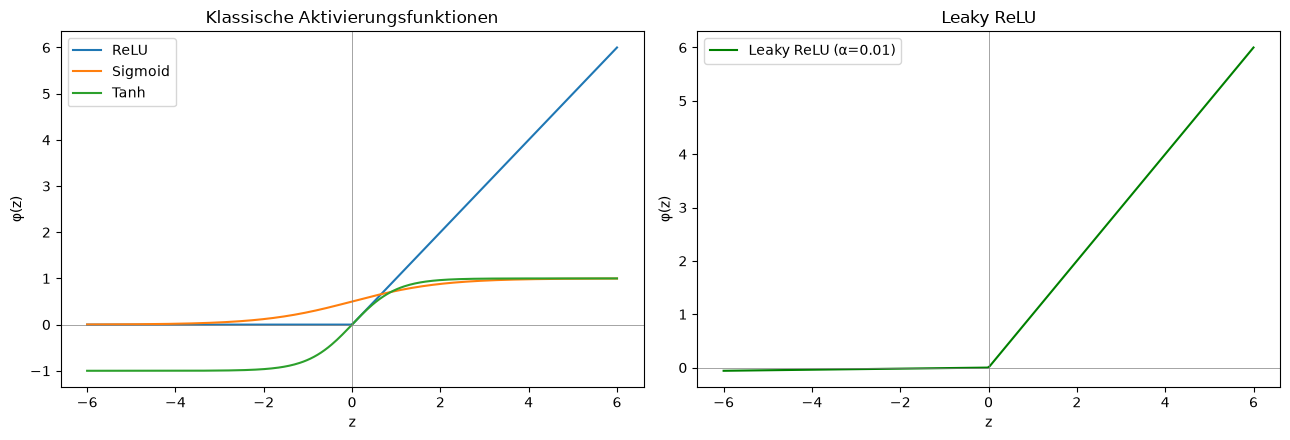

In [12]:
x_act = np.linspace(-6, 6, 300)

sigmoid = 1 / (1 + np.exp(-x_act))
tanh = np.tanh(x_act)
relu = np.maximum(0, x_act)
leaky_relu = np.where(x_act > 0, x_act, 0.01 * x_act)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(x_act, relu, label="ReLU")
axes[0].plot(x_act, sigmoid, label="Sigmoid")
axes[0].plot(x_act, tanh, label="Tanh")
axes[0].axhline(0, color="gray", linewidth=0.5)
axes[0].axvline(0, color="gray", linewidth=0.5)
axes[0].set_title("Klassische Aktivierungsfunktionen")
axes[0].set_xlabel("z")
axes[0].set_ylabel("φ(z)")
axes[0].legend()

axes[1].plot(x_act, leaky_relu, label="Leaky ReLU (α=0.01)", color="green")
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].axvline(0, color="gray", linewidth=0.5)
axes[1].set_title("Leaky ReLU")
axes[1].set_xlabel("z")
axes[1].set_ylabel("φ(z)")
axes[1].legend()

plt.tight_layout()
plt.show()

**Aktivierungen und Gradient-Flow:** Sigmoid und Tanh sättigen bei großen $|z|$ – die Ableitung geht dort gegen 0, wodurch der Gradient beim Backpropagation-Schritt durch viele Schichten hindurch "verschwinden" kann (*Vanishing Gradients*). ReLU hat für $z>0$ eine konstante Ableitung von 1 und löst dieses Problem größtenteils, weshalb ReLU heute der Standard für Hidden-Layer ist. Wir vertiefen dieses Thema in Kapitel 8 (Regularisierung & Stabilität).


### Architektur und Modellkapazität

Ein wichtiger praktischer Punkt: Die Anzahl der Parameter eines neuronalen Netzes wächst schnell mit Anzahl und Größe der Schichten.

Beispiel: Eingabedimension $d = 10$.

* **Variante A**: 1 Hidden-Layer mit 16 Neuronen, 1 Output-Neuron
  Gewichte: $10 \cdot 16 + 16 \cdot 1 = 176$, Biases: $16+1=17$ → **193 Parameter**
* **Variante B**: 2 Hidden-Layer mit je 16 Neuronen
  Gewichte: $10 \cdot 16 + 16 \cdot 16 + 16 \cdot 1 = 432$, Biases: $16+16+1=33$ → **465 Parameter**

Mehr Layer bzw. Neuronen bedeuten mehr Kapazität und Flexibilität – aber auch ein höheres Risiko für Overfitting und eine schwierigere Optimierung.


In [13]:
def count_mlp_parameters(input_dim, hidden_sizes, output_dim=1):
    '''Zählt Gewichte und Biases eines vollvernetzten MLP.'''
    sizes = [input_dim] + list(hidden_sizes) + [output_dim]
    total = 0
    for n_in, n_out in zip(sizes[:-1], sizes[1:]):
        total += n_in * n_out  # Gewichte
        total += n_out         # Biases
    return total

print("Variante A (1x16):", count_mlp_parameters(10, [16]), "Parameter")
print("Variante B (2x16):", count_mlp_parameters(10, [16, 16]), "Parameter")
print("Größeres Netz (3x128):", count_mlp_parameters(10, [128, 128, 128]), "Parameter")

Variante A (1x16): 193 Parameter
Variante B (2x16): 465 Parameter
Größeres Netz (3x128): 34561 Parameter


### Fazit Kapitel 4

* Ein Neuron berechnet $z = w^\top x + b$ und wendet eine Aktivierungsfunktion $\varphi$ an – strukturell identisch zur logistischen Regression.
* Erst das Stapeln vieler Neuronen in Schichten und das Hintereinanderschalten mehrerer Schichten erzeugt die Ausdruckskraft neuronaler Netze.
* Aktivierungsfunktionen sind unverzichtbar – ohne sie bliebe das Netz linear.
* Mehr Schichten/Neuronen = mehr Kapazität, aber auch mehr Parameter und höheres Overfitting-Risiko.

Als Nächstes schauen wir uns an, **wie** ein neuronales Netz aus einer Eingabe eine Vorhersage berechnet (Forward Pass) und wie der Fehler gemessen wird (Loss).


## Kapitel 5: Forward Pass & Loss – Wie ein Netz rechnet

### Forward Pass

Beim **Forward Pass** wird die Eingabe $x$ Schicht für Schicht durch das Netz propagiert:

$$
h^{(l)} = \varphi\!\left(W^{(l)} h^{(l-1)} + b^{(l)}\right)
$$

Am Ende entsteht ein **Logit** (unskalierter Wert) bzw. nach einer finalen Aktivierung eine **Wahrscheinlichkeit**. Für binäre Klassifikation mit einem Hidden-Layer:

$$
z^{(1)} = W^{(1)} x + b^{(1)}, \qquad h^{(1)} = \varphi\!\left(z^{(1)}\right)
$$
$$
z^{(2)} = W^{(2)} h^{(1)} + b^{(2)}, \qquad \hat y = \sigma\!\left(z^{(2)}\right)
$$

Der Wert $z^{(2)}$ heißt **Logit**: er kann beliebige reelle Werte annehmen. Die Sigmoid-Funktion $\sigma(z) = \frac{1}{1+e^{-z}}$ wandelt ihn in eine Wahrscheinlichkeit $\hat y \in (0,1)$ um.

Wir rechnen diesen Forward Pass jetzt **von Hand** an einem kleinen Beispiel nach, genau wie in der Vorlesung.


In [14]:
# Kleines Beispielnetz: 2 Inputs -> 1 Hidden Layer (2 Neuronen, ReLU) -> 1 Output (Sigmoid)

x = np.array([1.0, 2.0])

W1 = np.array([[0.4, -0.3],
               [0.1,  0.5]])
b1 = np.array([0.0, 0.0])

W2 = np.array([0.5, 0.8])
b2 = -0.1

def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# --- Schritt 1: Lineare Transformation, Hidden Layer ---
z1 = W1 @ x + b1
print("z^(1) =", z1)

# --- Schritt 2: Aktivierung (ReLU), Hidden Layer ---
h1 = relu(z1)
print("h^(1) =", h1)

# --- Schritt 3: Lineare Transformation, Output Layer ---
z2 = W2 @ h1 + b2
print("z^(2) =", z2)

# --- Schritt 4: Aktivierung (Sigmoid), Output Layer ---
y_hat = sigmoid(z2)
print("y_hat =", round(float(y_hat), 3))

z^(1) = [-0.2  1.1]
h^(1) = [0.  1.1]
z^(2) = 0.7800000000000001
y_hat = 0.686


Das Ergebnis $\hat y \approx 0.686$ ist die vom Netz geschätzte Wahrscheinlichkeit für Klasse 1. Als Nächstes berechnen wir, **wie falsch** diese Vorhersage ist – abhängig vom tatsächlichen Label.

### Loss-Funktion: Binary Cross-Entropy

Für binäre Klassifikation verwenden wir praktisch immer die **Binary Cross-Entropy (BCE)**:

$$
L(y, \hat y) = -\Big[y \log(\hat y) + (1-y)\log(1-\hat y)\Big]
$$

Eigenschaften:

* starke Bestrafung falscher, *selbstsicherer* Vorhersagen
* glatt und gut ableitbar → ideal für Gradientenabstieg
* entspricht der Minimierung der KL-Divergenz zwischen wahrer Verteilung und Modellvorhersage


In [15]:
def bce_loss(y, y_hat):
    return -(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

loss_y1 = bce_loss(1, y_hat)
loss_y0 = bce_loss(0, y_hat)

print(f"Vorhersage y_hat = {float(y_hat):.3f}")
print(f"Loss, falls y=1 (richtig vorhergesagt): L = {float(loss_y1):.3f}")
print(f"Loss, falls y=0 (falsch vorhergesagt):  L = {float(loss_y0):.3f}")

Vorhersage y_hat = 0.686
Loss, falls y=1 (richtig vorhergesagt): L = 0.377
Loss, falls y=0 (falsch vorhergesagt):  L = 1.157


**Interpretation:** Ist das wahre Label $y=1$, ist der Loss klein (≈ 0.377), da die Vorhersage ($\hat y \approx 0.686$) in die richtige Richtung zeigt. Ist das wahre Label dagegen $y=0$, ist der Loss deutlich größer (≈ 1.159), da das Modell mit $\hat y \approx 0.686$ eher auf Klasse 1 tippt, obwohl die wahre Klasse 0 ist. Dieser Loss-Wert ist genau das Signal, das im nächsten Schritt (Backpropagation) zur Anpassung der Gewichte verwendet wird.


### Warum nicht einfach MSE?

Man könnte auch den quadratischen Fehler (MSE) $L = \frac{1}{2}(\hat y - y)^2$ verwenden – dieser wird für Regressionsprobleme auch eingesetzt. Für Klassifikation ist BCE jedoch überlegen:

* MSE in Kombination mit Sigmoid sättigt bei extremen Vorhersagen → sehr kleine Gradienten → langsames Training.
* BCE bestraft grobe Fehleinschätzungen (Loss → ∞) deutlich stärker, was zu größeren, hilfreicheren Gradienten führt.
* BCE ist theoretisch optimal im Sinne der Maximum-Likelihood-Schätzung.


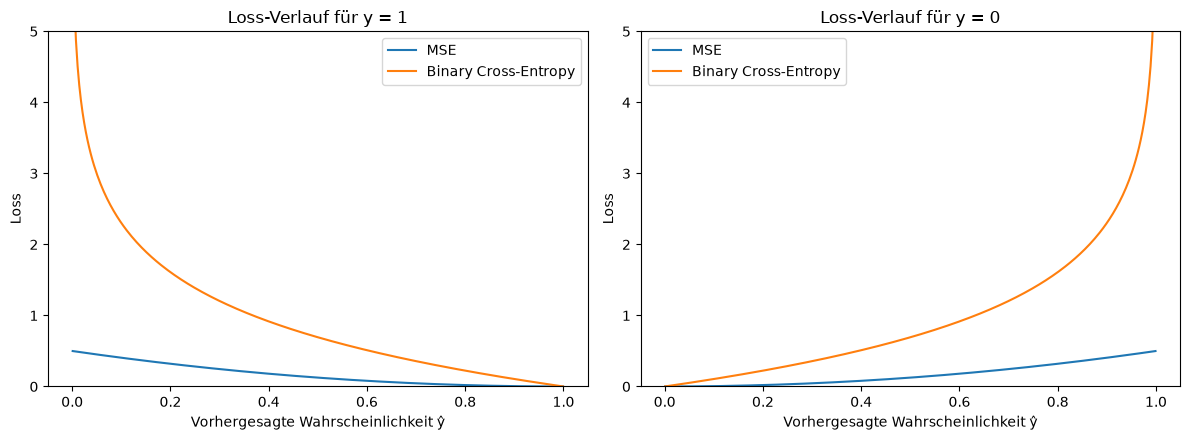

In [16]:
y_hat_range = np.linspace(0.001, 0.999, 300)

mse_y1 = 0.5 * (y_hat_range - 1) ** 2
bce_y1 = -np.log(y_hat_range)

mse_y0 = 0.5 * (y_hat_range - 0) ** 2
bce_y0 = -np.log(1 - y_hat_range)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(y_hat_range, mse_y1, label="MSE")
axes[0].plot(y_hat_range, bce_y1, label="Binary Cross-Entropy")
axes[0].set_title("Loss-Verlauf für y = 1")
axes[0].set_xlabel("Vorhergesagte Wahrscheinlichkeit ŷ")
axes[0].set_ylabel("Loss")
axes[0].set_ylim(0, 5)
axes[0].legend()

axes[1].plot(y_hat_range, mse_y0, label="MSE")
axes[1].plot(y_hat_range, bce_y0, label="Binary Cross-Entropy")
axes[1].set_title("Loss-Verlauf für y = 0")
axes[1].set_xlabel("Vorhergesagte Wahrscheinlichkeit ŷ")
axes[1].set_ylabel("Loss")
axes[1].set_ylim(0, 5)
axes[1].legend()

plt.tight_layout()
plt.show()

### Fazit Kapitel 5

* Der **Forward Pass** propagiert die Eingabe Schicht für Schicht: lineare Transformation gefolgt von Aktivierungsfunktion.
* Der finale Output eines Klassifikationsnetzes ist (nach Sigmoid bzw. Softmax) eine Wahrscheinlichkeit.
* Der **Loss** (bei binärer Klassifikation meist Binary Cross-Entropy) misst, wie stark die Vorhersage vom wahren Label abweicht.
* Ziel des Trainings ist es, die Gewichte so anzupassen, dass der Loss über alle Trainingsbeispiele minimal wird – das ist Thema des nächsten Kapitels.


## Kapitel 6: Training – Backpropagation und Gradientenabstieg

**Ziel:** Die Parameter $\theta = (W, b)$ aller Schichten so anpassen, dass der Loss $L(\theta)$ auf den Trainingsdaten möglichst klein wird.

Das Netz definiert eine Funktion $x \mapsto \hat y(x;\theta)$ und damit einen Loss $L(\theta)$. Wir aktualisieren die Parameter iterativ per **Gradientenabstieg**:

$$
\theta_{\text{neu}} = \theta_{\text{alt}} - \eta \, \nabla_\theta L(\theta_{\text{alt}})
$$

mit Lernrate $\eta > 0$. Dafür benötigen wir die Ableitung des Loss nach **jedem einzelnen** Gewicht und Bias – bei tausenden Parametern eine algorithmisch anspruchsvolle Aufgabe. Genau das leistet die **Backpropagation**: Mithilfe der Kettenregel wird der Fehler vom Output-Layer rückwärts durch das Netz "durchgereicht", wobei in jeder Schicht wiederverwendbare Zwischenergebnisse (Fehlerterme $\delta^{(l)}$) entstehen.

Für unser Beispiel eines einzelnen Neurons mit Sigmoid-Aktivierung und BCE-Loss ergibt sich eine besonders elegante Formel für den Fehlerterm am Output:

$$
\frac{\partial L}{\partial z} = \hat y - y
$$

Dieser Ausdruck – "Vorhersage minus Wahrheit" – ist das Herzstück des Backpropagation-Signals und wird von dort rückwärts durch alle vorherigen Schichten propagiert.

**Wichtig für dieses Notebook:** Wir implementieren Backpropagation *nicht* manuell für ein ganzes Netz – das übernehmen Bibliotheken wie `scikit-learn`, `PyTorch` oder `TensorFlow` vollautomatisch. Uns interessiert hier die **Intuition**: Backpropagation liefert die Richtung im Parameterraum, entlang derer der Loss am stärksten sinkt.


### Loss-Landschaft und Gradientenabstieg

Um die Intuition zu festigen, betrachten wir ein einzelnes Neuron mit Sigmoid-Aktivierung und BCE-Loss auf einem einzigen Trainingspunkt $(x=1, y=1)$. Jeder Punkt $(w, b)$ im folgenden Diagramm beschreibt ein mögliches Modell; die Farbe zeigt den zugehörigen Loss. Der Gradient zeigt stets in Richtung des **steilsten Anstiegs** – beim Training laufen wir also in die **entgegengesetzte** Richtung.


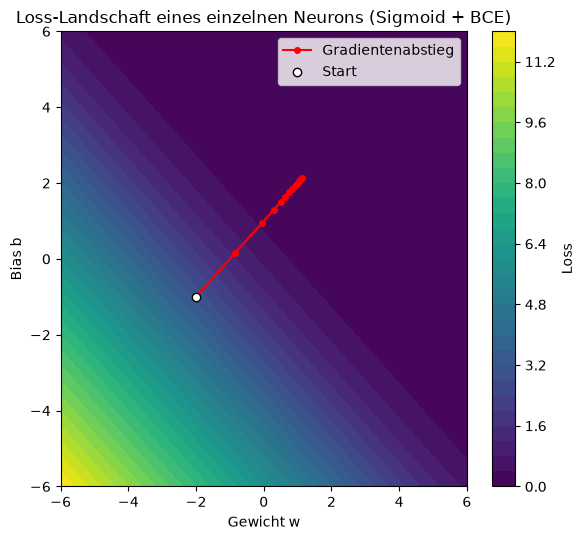

In [17]:
def sigmoid_(z):
    return 1 / (1 + np.exp(-z))

def bce_(y, y_hat, eps=1e-9):
    return -(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))

x_point, y_point = 1.0, 1  # ein Trainingsbeispiel

ws = np.linspace(-6, 6, 200)
bs = np.linspace(-6, 6, 200)
WW, BB = np.meshgrid(ws, bs)
loss_surface = bce_(y_point, sigmoid_(WW * x_point + BB))

# Gradientenabstieg von einem Startpunkt aus
w, b = -2.0, -1.0
lr = 1.2
path = [(w, b)]
for step in range(12):
    z = w * x_point + b
    y_hat = sigmoid_(z)
    grad = y_hat - y_point          # dL/dz  (Kernformel Backprop, ein Neuron)
    w = w - lr * grad * x_point     # dL/dw = grad * x
    b = b - lr * grad               # dL/db = grad
    path.append((w, b))
path = np.array(path)

fig, ax = plt.subplots(figsize=(6, 5.5))
cs = ax.contourf(WW, BB, loss_surface, levels=30, cmap="viridis")
plt.colorbar(cs, label="Loss")
ax.plot(path[:, 0], path[:, 1], "o-", color="red", markersize=4, label="Gradientenabstieg")
ax.scatter([path[0, 0]], [path[0, 1]], color="white", edgecolor="black", zorder=5, label="Start")
ax.set_xlabel("Gewicht w")
ax.set_ylabel("Bias b")
ax.set_title("Loss-Landschaft eines einzelnen Neurons (Sigmoid + BCE)")
ax.legend()
plt.tight_layout()
plt.show()

Man erkennt deutlich, wie der Gradientenabstieg Schritt für Schritt "bergab" in Richtung des Minimums läuft. Bei einem vollständigen Netz mit tausenden Parametern passiert genau dasselbe – nur eben in einem sehr viel höherdimensionalen Raum, den wir nicht mehr visualisieren können. Die Idee bleibt aber identisch.

### Ein Trainingsschritt im Überblick

Für ein Batch von Trainingsbeispielen läuft ein Trainingsschritt immer nach demselben Schema ab:

1. **Forward Pass**: Eingaben durch alle Layer propagieren, Vorhersage $\hat y$ berechnen.
2. **Loss berechnen**: $L = \ell(\hat y, y)$ für das Batch.
3. **Backward Pass (Backpropagation)**: Fehlerterme vom Output-Layer rückwärts durch das Netz propagieren, Gradienten $\partial L / \partial W^{(l)}$ und $\partial L / \partial b^{(l)}$ berechnen.
4. **Update**: Parameter in Richtung des negativen Gradienten anpassen.

Dieser Ablauf wird für viele Batches und über mehrere Epochen (vollständige Durchläufe durch den Trainingsdatensatz) wiederholt.


### Fazit Kapitel 6

* Ziel des Trainings ist die Minimierung des Loss über alle Trainingsbeispiele mittels **Gradientenabstieg**.
* **Backpropagation** berechnet effizient alle benötigten Gradienten mithilfe der Kettenregel, indem der Fehler vom Output rückwärts durch das Netz propagiert wird.
* In der Praxis übernehmen ML-Bibliotheken diese Berechnung automatisch (*automatic differentiation*) – wir müssen die Kettenregel nicht von Hand anwenden.
* Wichtige Stellschrauben dieses Prozesses (Lernrate, Batch Size, Optimizer) betrachten wir im nächsten Kapitel.


## Kapitel 7: Hyperparameter des Trainings

### Lernrate (Learning Rate)

Die Lernrate $\eta$ im Gradientenabstieg-Update $\theta_{\text{neu}} = \theta_{\text{alt}} - \eta \cdot \nabla L$ bestimmt die Schrittweite:

* $\eta$ **zu klein** → Lernen ist langsam, aber stabil.
* $\eta$ **passend** → schnelle, stabile Konvergenz.
* $\eta$ **zu groß** → das Modell "springt" über das Minimum hinweg, das Training kann divergieren.

Wir illustrieren das anhand einer einfachen quadratischen Loss-Funktion $f(\theta) = \theta^2$.


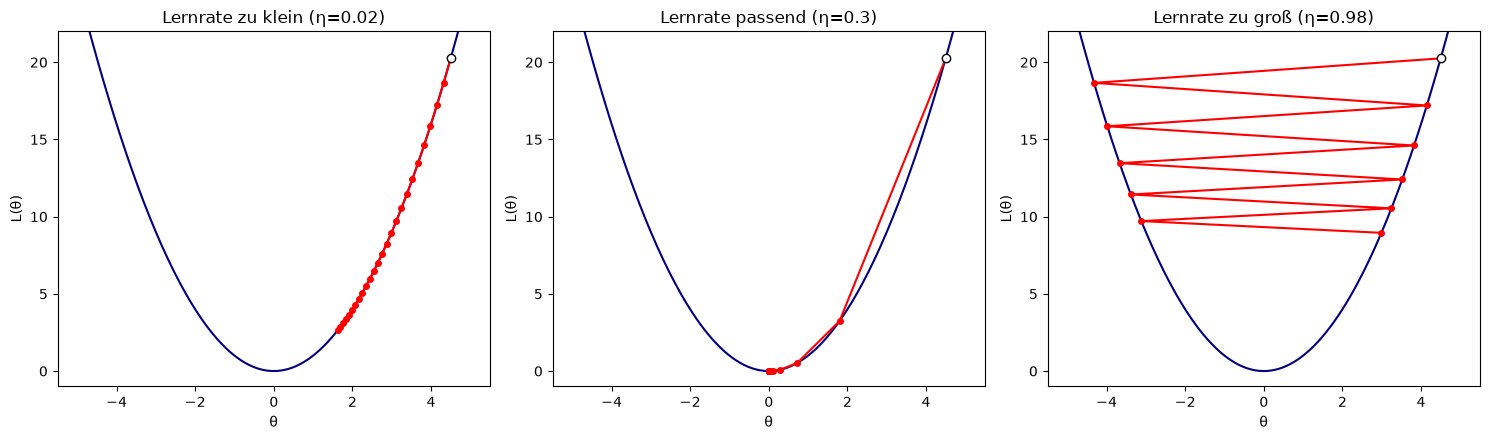

In [18]:
def f(theta):
    return theta ** 2

def grad_f(theta):
    return 2 * theta

theta_start = 4.5
theta_curve = np.linspace(-5, 5, 200)

settings = [
    ("Lernrate zu klein (η=0.02)", 0.02, 25),
    ("Lernrate passend (η=0.3)",   0.30, 15),
    ("Lernrate zu groß (η=0.98)",  0.98, 10),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (title, lr, n_steps) in zip(axes, settings):
    theta = theta_start
    path = [theta]
    for _ in range(n_steps):
        theta = theta - lr * grad_f(theta)
        path.append(theta)
    path = np.array(path)

    ax.plot(theta_curve, f(theta_curve), color="navy")
    ax.plot(path, f(path), "o-", color="red", markersize=4)
    ax.scatter([path[0]], [f(path[0])], color="white", edgecolor="black", zorder=5)
    ax.set_title(title)
    ax.set_xlabel("θ")
    ax.set_ylabel("L(θ)")
    ax.set_ylim(-1, 22)

plt.tight_layout()
plt.show()

### Optimizer: GD, SGD, Mini-Batch, Adam

* **Gradient Descent (GD, "Full Batch")**: nutzt bei jedem Update den *gesamten* Trainingsdatensatz – stabil, aber teuer bei großen Datenmengen.
* **Stochastic Gradient Descent (SGD)**: nutzt bei jedem Update nur ein einzelnes Beispiel – sehr "wackelig", aber schnell und mit guter Exploration.
* **Mini-Batch SGD**: nutzt eine kleine Teilmenge ("Batch") von Beispielen pro Update – die in der Praxis übliche Balance zwischen Stabilität und Tempo.
* **Adam**: adaptiver Optimizer, passt die effektive Lernrate pro Parameter automatisch an – funktioniert in der Praxis meist "out of the box" sehr gut und ist heute Standard.

### Batch Size und Epochen

* **Batch Size**: Anzahl Beispiele, die gleichzeitig für einen Gradientenschritt verwendet werden (typisch: 16, 32, 64, …).
* **Epoche**: ein vollständiger Durchlauf durch den gesamten Trainingsdatensatz.

Bei $N$ Beispielen gilt:

$$
\#\text{Iterationen pro Epoche} = \frac{N}{\text{Batch Size}}
$$

Modelle werden in der Regel über mehrere Epochen hinweg besser, da jede Epoche die Gewichte weiter in Richtung des Optimums korrigiert – solange kein Overfitting eintritt (siehe Kapitel 8).


### Fazit Kapitel 7

* Die **Lernrate** ist einer der wichtigsten Hyperparameter überhaupt: zu klein → langsam, zu groß → instabil.
* **Adam** ist heute meist die Standardwahl unter den Optimizern.
* **Batch Size** und **Anzahl Epochen** steuern, wie oft und auf welcher Datenbasis die Gewichte aktualisiert werden.

Bevor wir ein neuronales Netz auf dem Titanic-Datensatz trainieren, schauen wir uns an, wie wir Overfitting bei so vielen Parametern in den Griff bekommen.


## Kapitel 8: Regularisierung & Stabilität

### Warum brauchen neuronale Netze Regularisierung?

Neuronale Netze haben oft sehr viele Parameter – bereits ein kleines Netz mit 1000 Inputs und einer Hidden-Schicht mit 100 Neuronen hat $1000 \times 100 = 100\,000$ Gewichte. Das bedeutet:

* hohe Flexibilität, aber auch **hohes Overfitting-Risiko**
* die Loss-Landschaft ist nicht-konvex → empfindlich gegenüber Rauschen in den Daten
* Aktivierungen können "explodieren" oder komplett "absterben"

Ziel der Regularisierung ist es, die gelernten Repräsentationen zu stabilisieren, robustere Entscheidungsgrenzen zu lernen und zu verhindern, dass das Modell die Trainingsdaten schlicht auswendig lernt.

### Weight Decay (L2-Regularisierung)

Große Gewichte führen zu instabilen, extrem "ausgefransten" Modellen. Weight Decay bestraft große Gewichte im Loss:

$$
L_{\text{total}} = L_{\text{data}} + \lambda \lVert W \rVert_2^2
$$

Das Netz wird so gezwungen, nur die wirklich nötige Komplexität zu nutzen. In `scikit-learn`'s `MLPClassifier` entspricht dies dem Parameter `alpha`.

### Dropout

Beim **Dropout** werden während des Trainings zufällig Neuronen deaktiviert (z. B. mit Wahrscheinlichkeit 50 %). Jedes Trainings-Batch "sieht" dadurch ein anderes Subnetz, sodass sich das Modell nicht auf einzelne Neuronen verlassen kann – das Ergebnis ist eine robustere, verteiltere Repräsentation. Dropout ist Standard in modernen Deep-Learning-Frameworks (PyTorch, TensorFlow/Keras); das hier verwendete `scikit-learn` bietet dafür allerdings **keine eingebaute Option** – ein Punkt, den wir im Fazit dieses Notebooks nochmal aufgreifen.

### Vanishing & Exploding Gradients

In tiefen Netzen werden die Gradienten beim Backpropagation-Schritt über viele Schichten hinweg **multipliziert**:

$$
g^{(l)} = g^{(l+1)} W^{(l+1)} \varphi'\!\left(z^{(l)}\right)
$$

* Ist $\varphi'$ klein (wie bei Sigmoid/Tanh im gesättigten Bereich): Der Gradient **verschwindet** über viele Schichten hinweg ("Vanishing Gradients") → frühe Schichten lernen kaum noch.
* Sind die Gewichte groß: Der Gradient **explodiert** → das Training wird instabil oder divergiert.

**Gängige Lösungsansätze:**

* Verwendung von **ReLU** statt Sigmoid/Tanh in Hidden-Layern (konstante Ableitung im positiven Bereich)
* geeignete **Gewichtsinitialisierung** (z. B. Xavier- oder He-Initialisierung)
* **Batch Normalization** (Normalisierung der Aktivierungen zwischen den Schichten)
* **Early Stopping**: Training abbrechen, sobald sich die Performance auf einem Validierungsset nicht mehr verbessert


### Fazit Kapitel 8

* Neuronale Netze mit vielen Parametern neigen stark zu **Overfitting** – Regularisierung ist essenziell.
* **Weight Decay (L2)** bestraft große Gewichte, **Dropout** deaktiviert zufällig Neuronen während des Trainings.
* **Vanishing/Exploding Gradients** sind ein Trainingsproblem in tiefen Netzen; ReLU-Aktivierungen, gute Initialisierung und Batch Normalization helfen dagegen.

Damit haben wir alle konzeptionellen Bausteine beisammen. Jetzt wenden wir sie praktisch auf den Titanic-Datensatz an.


## Kapitel 9: Ein neuronales Netz auf dem Titanic-Datensatz

In `scikit-learn` steht mit `MLPClassifier` ("Multi-Layer Perceptron") eine einfache, aber vollwertige Implementierung eines Feedforward-Netzes zur Verfügung. Wir binden sie – wie alle bisherigen Modelle – in unsere gewohnte Preprocessing-Pipeline ein.

Wichtige Parameter:

* `hidden_layer_sizes`: Architektur, z. B. `(32, 16)` = zwei Hidden-Layer mit 32 bzw. 16 Neuronen
* `activation`: Aktivierungsfunktion der Hidden-Layer (Standard: `"relu"`)
* `solver`: Optimierer (`"adam"` ist Standard und meist eine gute Wahl)
* `alpha`: Stärke der L2-Regularisierung (Weight Decay)
* `learning_rate_init`: Start-Lernrate
* `max_iter`: maximale Anzahl an Epochen
* `early_stopping`: bricht das Training ab, sobald sich die Validierungs-Performance nicht mehr verbessert


=== Neuronales Netz (MLP) ===
 Train-Accuracy: 0.841
       Accuracy: 0.838
      Precision: 0.870
         Recall: 0.681
             F1: 0.764
        ROC-AUC: 0.872



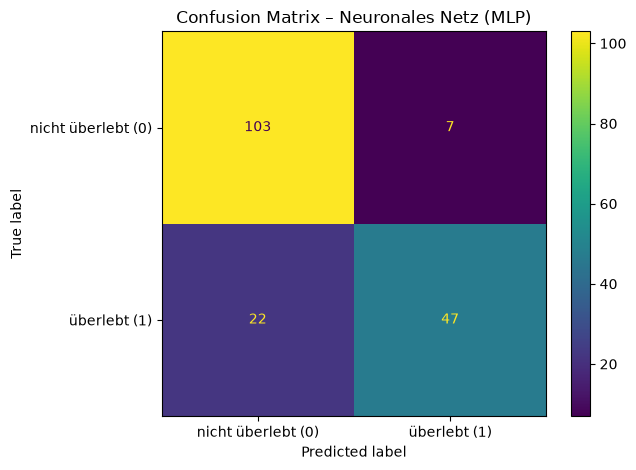

In [19]:
from sklearn.neural_network import MLPClassifier

mlp_clf = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", MLPClassifier(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            solver="adam",
            alpha=1e-3,               # Weight Decay (L2)
            learning_rate_init=1e-3,
            max_iter=1000,
            early_stopping=True,
            n_iter_no_change=15,
            random_state=42
        ))
    ]
)

mlp_metrics = evaluate_model(
    name="Neuronales Netz (MLP)",
    model=mlp_clf,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    plot_cm=True
)

### Trainingsverlauf: die Loss-Kurve

`MLPClassifier` speichert den Verlauf des Trainings-Loss über die Epochen im Attribut `loss_curve_`. Dieser Verlauf zeigt anschaulich, wie der Gradientenabstieg den Loss Epoche für Epoche reduziert.


In [ ]:
loss_curve = mlp_clf.named_steps["model"].loss_curve_

plt.figure(figsize=(7, 4.5))
plt.plot(loss_curve)
plt.xlabel("Epoche")
plt.ylabel("Trainings-Loss (Binary Cross-Entropy)")
plt.title("Trainingsverlauf des neuronalen Netzes")
plt.tight_layout()
plt.show()

print(f"Anzahl trainierter Epochen: {len(loss_curve)}")
print(f"Finaler Trainings-Loss: {loss_curve[-1]:.4f}")

### Fazit Kapitel 9

* `MLPClassifier` lässt sich genauso einfach in unsere Pipeline einbinden wie die bisherigen Modelle.
* Die Loss-Kurve zeigt den typischen Verlauf: schneller Abfall zu Beginn, danach Abflachen – dies ist die Gradientenabstieg-Optimierung "in Aktion".
* Die erzielte Performance liegt in einer ähnlichen Größenordnung wie die Baseline-Modelle. Ob und wie sich das mit anderen Hyperparametern verbessern lässt, untersuchen wir im nächsten Kapitel.


## Kapitel 10: Hyperparameter-Tuning & Overfitting in der Praxis

Wir untersuchen nun konkret, wie sich zwei zentrale Hyperparameter auf **Trainings-** und **Test-Accuracy** auswirken:

1. Die **Netzarchitektur** (Anzahl und Größe der Hidden-Layer) – mehr Kapazität führt tendenziell zu Overfitting.
2. Die Stärke der **L2-Regularisierung** (`alpha`) – mehr Regularisierung sollte Overfitting entgegenwirken.


In [20]:
architectures = {
    "1 Layer, klein (8)":        (8,),
    "1 Layer, mittel (32)":      (32,),
    "2 Layer (64, 32)":          (64, 32),
    "3 Layer (128, 64, 32)":     (128, 64, 32),
}

arch_results = []

for name, hidden in architectures.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", MLPClassifier(
            hidden_layer_sizes=hidden,
            max_iter=1000,
            early_stopping=True,
            random_state=42
        ))
    ])
    pipe.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, pipe.predict(X_train))
    test_acc = accuracy_score(y_test, pipe.predict(X_test))
    n_params = count_mlp_parameters(
        input_dim=len(feature_names_all),
        hidden_sizes=hidden
    )

    arch_results.append({
        "Architektur": name,
        "#Parameter": n_params,
        "Train-Accuracy": train_acc,
        "Test-Accuracy": test_acc,
        "Gap (Train-Test)": train_acc - test_acc,
    })

arch_df = pd.DataFrame(arch_results)
arch_df

,Architektur,#Parameter,Train-Accuracy,Test-Accuracy,Gap (Train-Test)
0,"1 Layer, klein (8)",233,0.835674,0.810056,0.025618
1,"1 Layer, mittel (32)",929,0.792135,0.782123,0.010012
2,"2 Layer (64, 32)",3905,0.825843,0.815642,0.010200
3,"3 Layer (128, 64, 32)",13953,0.827247,0.826816,0.000432


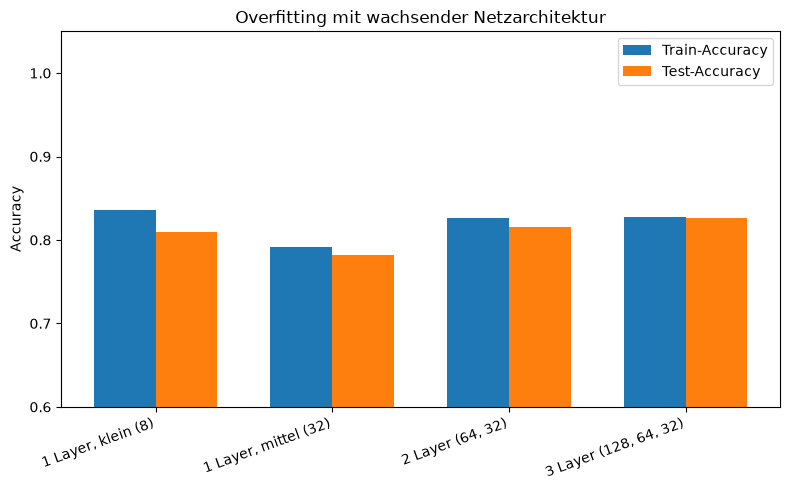

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(arch_df))
width = 0.35

ax.bar(x_pos - width/2, arch_df["Train-Accuracy"], width, label="Train-Accuracy")
ax.bar(x_pos + width/2, arch_df["Test-Accuracy"], width, label="Test-Accuracy")

ax.set_xticks(x_pos)
ax.set_xticklabels(arch_df["Architektur"], rotation=20, ha="right")
ax.set_ylabel("Accuracy")
ax.set_title("Overfitting mit wachsender Netzarchitektur")
ax.legend()
ax.set_ylim(0.6, 1.05)

plt.tight_layout()
plt.show()

**Beobachtung:** Mit wachsender Netzgröße steigt die **Trainings**-Accuracy tendenziell an (bis hin zu (nahezu) perfektem Auswendiglernen), während die **Test**-Accuracy stagniert oder sogar sinkt – die Lücke zwischen beiden ("Gap") ist ein direktes Maß für Overfitting. Das ist exakt das Verhalten, das wir aus Kapitel 8 erwartet haben.

Nun betrachten wir den Effekt der **L2-Regularisierung** (`alpha`) bei fester, eher großer Architektur.


In [22]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1.0]
alpha_results = []

for alpha in alphas:
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", MLPClassifier(
            hidden_layer_sizes=(128, 64, 32),
            alpha=alpha,
            max_iter=1000,
            early_stopping=True,
            random_state=42
        ))
    ])
    pipe.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, pipe.predict(X_train))
    test_acc = accuracy_score(y_test, pipe.predict(X_test))

    alpha_results.append({"alpha": alpha, "Train-Accuracy": train_acc, "Test-Accuracy": test_acc})

alpha_df = pd.DataFrame(alpha_results)
alpha_df

,alpha,Train-Accuracy,Test-Accuracy
0,0.0001,0.827247,0.826816
1,0.0010,0.828652,0.826816
2,0.0100,0.827247,0.826816
3,0.1000,0.827247,0.826816
4,1.0000,0.820225,0.832402


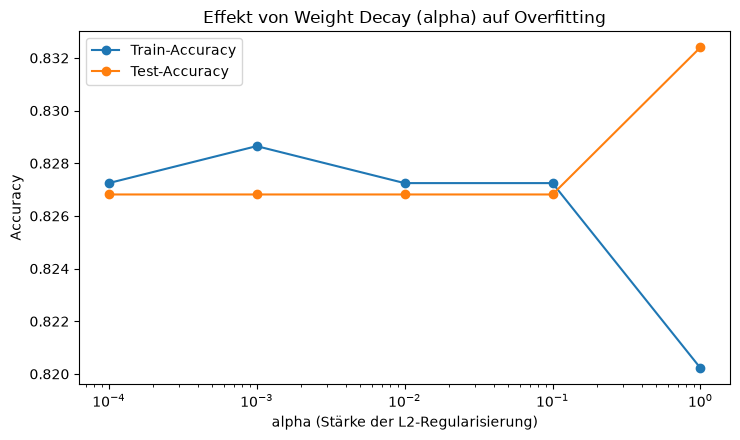

In [23]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(alpha_df["alpha"], alpha_df["Train-Accuracy"], "o-", label="Train-Accuracy")
ax.plot(alpha_df["alpha"], alpha_df["Test-Accuracy"], "o-", label="Test-Accuracy")
ax.set_xscale("log")
ax.set_xlabel("alpha (Stärke der L2-Regularisierung)")
ax.set_ylabel("Accuracy")
ax.set_title("Effekt von Weight Decay (alpha) auf Overfitting")
ax.legend()
plt.tight_layout()
plt.show()

**Beobachtung:** Mit steigendem `alpha` sinkt die Trainings-Accuracy leicht (das Modell "passt sich weniger stark an"), während die Test-Accuracy stabil bleibt oder sich sogar leicht verbessert – die Lücke zwischen Train und Test wird kleiner. Zu starke Regularisierung (sehr großes `alpha`) würde dagegen zu **Underfitting** führen, da dem Modell dann die nötige Flexibilität fehlt.

Das entspricht genau dem klassischen **Bias-Varianz-Trade-off**: zu wenig Regularisierung → hohe Varianz (Overfitting), zu viel Regularisierung → hoher Bias (Underfitting). In der Praxis würde man diese Hyperparameter systematisch per `GridSearchCV` oder `RandomizedSearchCV` mit Kreuzvalidierung optimieren – genau wie wir es bereits für Random Forests kennengelernt haben.


### Fazit Kapitel 10

* Größere Netzarchitekturen erhöhen die Kapazität und damit tendenziell das Overfitting-Risiko.
* Weight Decay (`alpha`) wirkt dem entgegen, indem große Gewichte bestraft werden.
* Die beste Konfiguration liegt meist irgendwo dazwischen – gefunden durch systematisches Tuning mit Kreuzvalidierung, genau wie bei den bereits bekannten Modellen.


## Kapitel 11: Gesamtvergleich aller Modelle

Zum Abschluss vergleichen wir alle in diesem Notebook trainierten Modelle anhand der zentralen Metriken.


In [24]:
comparison_df = pd.DataFrame({
    name: res["metrics"] for name, res in model_results.items()
}).T

comparison_df

,Train-Accuracy,Accuracy,Precision,Recall,F1,ROC-AUC
Logistische Regression,0.828652,0.826816,0.787879,0.753623,0.770370,0.863373
Entscheidungsbaum,0.855337,0.810056,0.777778,0.710145,0.742424,0.852437
Random Forest,0.984551,0.815642,0.810345,0.681159,0.740157,0.835639
Neuronales Netz (MLP),0.841292,0.837989,0.870370,0.681159,0.764228,0.872464


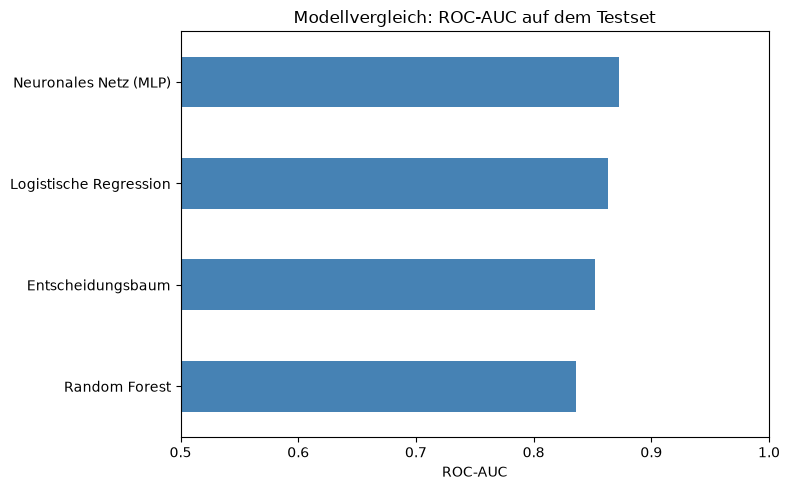

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
comparison_df["ROC-AUC"].sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("ROC-AUC")
ax.set_title("Modellvergleich: ROC-AUC auf dem Testset")
ax.set_xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

### Interpretation

Auf einem eher kleinen, tabellarischen Datensatz wie Titanic (rund 900 Zeilen, wenige Dutzend Features) liefert das neuronale Netz meist eine Performance **in derselben Größenordnung** wie Random Forest oder Boosting-Modelle – aber selten einen klaren Vorsprung. Das ist kein Zufall, sondern ein bekanntes, wichtiges Muster:

* **Baumbasierte Modelle (Random Forest, Boosting, XGBoost)** sind für tabellarische Daten mit gemischten, oft nicht standardisierten Features häufig die robustere und einfacher zu tunende Wahl.
* **Neuronale Netze** spielen ihre Stärken vor allem dann aus, wenn *sehr viele* Trainingsdaten vorhanden sind und/oder die Daten eine natürliche räumliche/sequentielle Struktur besitzen – etwa Bilder, Audio, Text oder Zeitreihen. Dort können sie automatisch hierarchische Repräsentationen lernen, die von Hand kaum zu konstruieren wären.
* Für kleine, tabellarische Datensätze ist der Aufwand für Preprocessing (zwingende Standardisierung!) und Hyperparameter-Tuning bei neuronalen Netzen oft höher, ohne dass ein entsprechender Performance-Gewinn winkt.

**Praktische Faustregel:** Bei tabellarischen Daten zuerst Gradient Boosting / XGBoost / Random Forest ausprobieren – neuronale Netze eher dann, wenn sehr viele Daten und/oder unstrukturierte Eingaben (Bilder, Text, Audio) vorliegen.


## Kapitel 12: Fazit & Ausblick

### Was haben wir gelernt?

* **Motivation**: Lineare Modelle und einzelne Bäume haben strukturelle Grenzen; neuronale Netze lernen automatisch nichtlineare Repräsentationen.
* **Bausteine**: Neuron ($z = w^\top x + b$, $a=\varphi(z)$), Schichten (Input/Hidden/Output), Aktivierungsfunktionen (Sigmoid, Tanh, ReLU).
* **Forward Pass & Loss**: Schrittweise Berechnung der Vorhersage; Binary Cross-Entropy als Standard-Loss für Klassifikation.
* **Training**: Gradientenabstieg minimiert den Loss; Backpropagation berechnet die dafür nötigen Gradienten effizient mittels Kettenregel.
* **Hyperparameter**: Lernrate, Optimizer (Adam), Batch Size und Epochen steuern den Trainingsprozess.
* **Regularisierung**: Weight Decay, Dropout und saubere Initialisierung/Aktivierungswahl (ReLU) stabilisieren das Training und reduzieren Overfitting.
* **Praxis**: `MLPClassifier` lässt sich nahtlos in unsere gewohnte scikit-learn-Pipeline integrieren; auf tabellarischen Daten wie Titanic liegt die Performance meist auf Augenhöhe mit Baum-Ensembles, aber nicht klar darüber.

### Grenzen dieses Notebooks

`scikit-learn`'s `MLPClassifier` ist ein guter Einstieg, aber für "echtes" Deep Learning in der Praxis unzureichend:

* Kein GPU-Training möglich.
* Kein Dropout, keine Batch Normalization.
* Keine Spezialarchitekturen (CNNs für Bilder, RNNs/Transformer für Sequenzen).

### Ausblick

Für ernsthafte Deep-Learning-Projekte kommen spezialisierte Frameworks zum Einsatz, allen voran **PyTorch** und **TensorFlow/Keras**. Sie bieten:

* automatische Differenzierung (Autograd) für beliebig komplexe Architekturen,
* GPU-Beschleunigung,
* Dropout, Batch Normalization und viele weitere Regularisierungstechniken,
* spezialisierte Schichten für Bilder (Convolutional Neural Networks), Sequenzen (RNNs, LSTMs) und moderne Architekturen (Transformer).

Diese Themen sind fester Bestandteil weiterführender Deep-Learning-Veranstaltungen.

**Nächste Einheit:** Im letzten Termin dieses Labs runden wir das Semester mit **Unsupervised Learning** (z. B. Clustering, Dimensionsreduktion) ab und schließen mit einem Nachtrag zu **XGBoost**.
